This notebook is to explore basic behavior of metrics. Basically making up different G matrices and looking at the correlations between metrics as an indication of whether they are capturing the same information.

In [1]:
import numpy as np
import OptimalBattery.util as ut
import matplotlib.pyplot as plt
import seaborn as sns

# diagonal Glib

In [2]:
G_lib = np.diag([1, 1, 1, 1, 1])
D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
print(len(D))
D

10


,variance,variance_mc,inverse_trace,inverse_trace_mc,log_det,log_det_mc,eigenvalues,num_eigenvalues,n_tasks,combination,n_unique
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(0, 1, 4)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(0, 2, 4)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(0, 3, 4)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(0, 1, 3)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(1, 2, 3)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(0, 2, 3)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(1, 3, 4)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(2, 3, 4)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(0, 1, 2)",3
0,3.0,2.0,-3.0,-2.0,0.0,0.0,"[1.0, 1.0]",2,3,"(1, 2, 4)",3


all metrics are just some function of the eigenvalues 

# Variable digaonal Glib, constant off-diagonal Glib

10


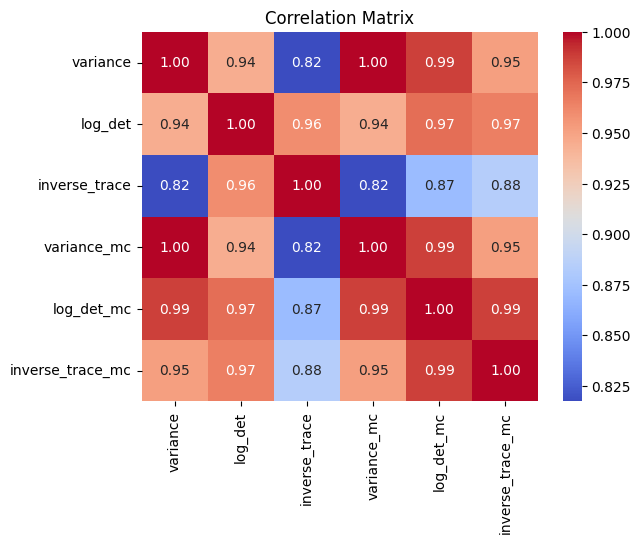

In [3]:
G_lib = np.diag([1, 0.7, 0.5, 0.3, 0.1])
D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
print(len(D))
metrics = ['variance', 'log_det', 'inverse_trace', 'variance_mc', 'log_det_mc', 'inverse_trace_mc']
correlation_matrix = D[metrics].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix')
plt.show()

varinace = variance_mc (highly correalted) - because no information in the offdiagonal to alter the information content in varianvr_mc

# constant digaonal, off diagonal variation

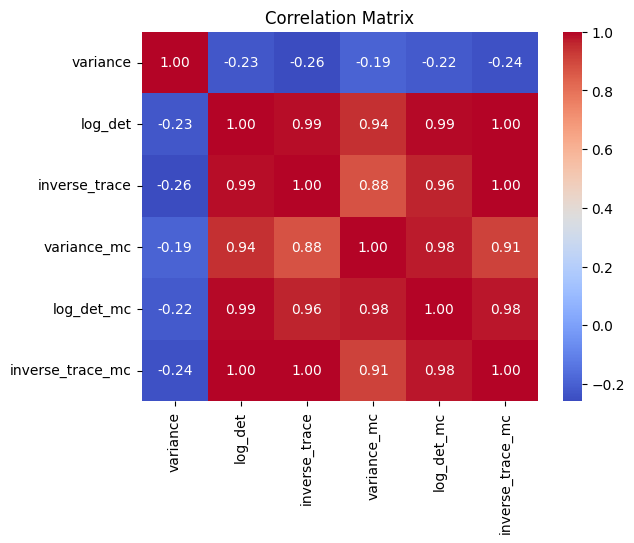

In [4]:
G_lib = np.array([[1 , 0.3, 0.5, 0.7, 0.3],
                    [0.3, 1, 0.5, 0.6, 0.2],
                    [0.5, 0.5, 1, 0.4, 0.3],
                    [0.7, 0.6, 0.4, 1, 0.6],
                    [0.3, 0.2, 0.3, 0.6, 1]])
D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
metrics = ['variance', 'log_det', 'inverse_trace', 'variance_mc', 'log_det_mc', 'inverse_trace_mc']
correlation_matrix = D[metrics].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix')
plt.show()


if we add in the off diagonal and keep digaonal constant, variance (only metric that does not consider offdiagonal) becomes uncorrelated with the rest which do

# variable diagonal and off diagonal

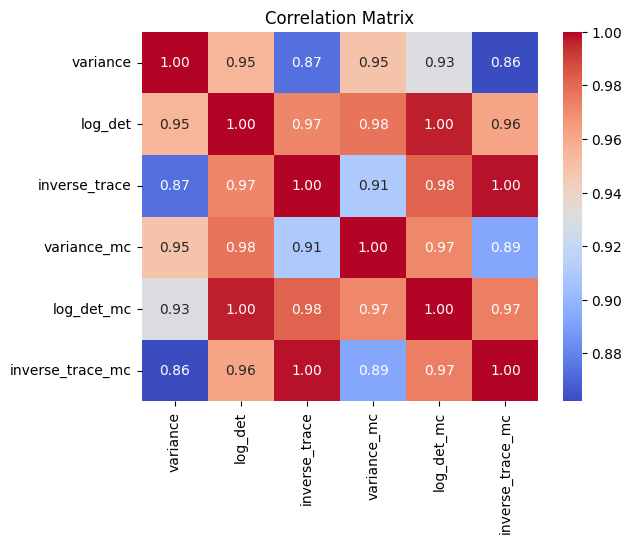

In [5]:
G_lib = np.array([
    [0.52, 0.28, 0.40, 0.35, 0.35],
    [0.28, 0.70, 0.30, 0.23, 0.45],
    [0.40, 0.30, 0.63, 0.37, 0.24],
    [0.35, 0.23, 0.37, 0.89, 0.27],
    [0.35, 0.45, 0.24, 0.27, 0.93]
])
D = ut.build_combinations(G_lib, strategy='random',n_iter=100,n_tasks=3,seed=605,replacement=False)
metrics = ['variance', 'log_det', 'inverse_trace', 'variance_mc', 'log_det_mc', 'inverse_trace_mc']
correlation_matrix = D[metrics].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.title('Correlation Matrix')
plt.show()


why is log_det perfectly correlated with log_det_mc??..